# Doughnut of Social and Planetary Boundaries

This notebook reproduces the summary tables for the social foundation (Table 1) and ecological ceiling (Table 2) from [Fanning & Raworth (2025)](https://www.nature.com/articles/s41586-025-09385-1), who examined progress toward meeting the needs of all people within the means of the living planet.

Data source: [Zenodo repository](https://doi.org/10.5281/zenodo.15688961), covering 35 indicators over the 2000–2022 period.

In [52]:
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt

BASE = os.path.join('a-fanning', 'a-fanning-doughnut-v3-a0460e5', 'Analysis-Final')


def style_summary_table(df):
    """Style an indicator summary DataFrame with centered headers and left-aligned text columns."""
    return (
        df.style
        .set_table_styles([
            {'selector': 'th.col_heading', 'props': 'text-align: center;'},
            {'selector': 'th.col_heading.level0', 'props': 'text-align: center;'},
            {'selector': 'th.col_heading.level1', 'props': 'text-align: center;'},
        ])
        .set_properties(
            subset=[('dimension', ''), ('indicator', '')],
            **{'text-align': 'left'},
        )
        .hide(axis='index')
        .format(
            {('value', 'first'): '{:.2f}', ('value', 'last'): '{:.2f}'},
        )
    )

## Part 1: The Social Foundation — Table 1

The social foundation defines the minimum level of human well-being below which critical deprivation exists. Fanning & Raworth track **21 indicators** across **12 dimensions** (food, health, education, energy, etc.), each measuring the share of the global population experiencing a specific form of deprivation.

Several raw indicators record *positive* outcomes (e.g., literacy rate, energy access) and are inverted (`100 − value`) to express the corresponding deprivation rate. Two indicators on a 0–1 scale (Gender Inequality Index and societal poverty) are rescaled to percentages.

The table below shows the **first and last available global values** for each indicator over the 2000–2022 period.

In [53]:
soc_files = sorted(glob.glob(os.path.join(BASE, 'cleanData', 'soc-*_clean.csv')))
soc_all = pd.concat([pd.read_csv(f) for f in soc_files], ignore_index=True)

# Keep only global ("World") observations with valid values
soc_world = soc_all[(soc_all['group'] == 'World') & soc_all['value'].notna()].copy()

# Map indicator codes to human-readable deprivation descriptions
SOCIAL_NAMES = {
    'internet': 'Population not accessing the internet',
    'publicTrans': (
        'Urban population lacking convenient access to public<br>transport'
    ),
    'adultLiteracy': 'Adult population (aged 15+ years) who are illiterate',
    'secondarySchool': (
        'Young adult population (aged 21-23 years) with<br>'
        'incomplete upper secondary education'
    ),
    'energyAccess': 'Population lacking access to electricity',
    'energyIndoor': (
        'Population lacking access to clean fuels and<br>'
        'technologies for cooking, heating and lighting'
    ),
    'genderGapIndex': (
        'Population-weighted score on the Gender Inequality<br>'
        'Index (global gap between women and men in terms of<br>'
        'reproductive health, empowerment and employment)'
    ),
    'foodInsecurity': 'Population with moderate to severe food insecurity',
    'undernourishment': 'Population undernourished',
    'UHCindex': (
        'Population living in countries without high coverage<br>'
        'of essential health services (Universal Health<br>'
        'Coverage Index score less than 60 out of 100)'
    ),
    'under5death': (
        'Population living in countries with under-5<br>'
        'mortality rate exceeding 25 per 1,000 live births'
    ),
    'urbanSlums': 'Urban population living in slums or informal settlements',
    'societalPoverty': (
        'Population living below the societal poverty line,<br>'
        " set at half their country's median household<br>"
        'income or at least $15 a day'
    ),
    'youthNEET': (
        'Population of young people (aged 15-24 years) not<br>'
        'in employment, education or training'
    ),
    'controlCorruption': (
        'Population stating that they perceive<br>'
        'widespread corruption in government and business'
    ),
    'homicideOver5': (
        'Population living in countries with a homicide rate<br>'
        'of 5 or more per 100,000'
    ),
    'govRegimes': 'Population living in countries governed by an autocratic regime',
    'palma': (
        'Population living in countries with a Palma ratio of 2 or more<br>'
        ' (the income share of the richest 10% of people relative<br>'
        'to the poorest 40%)'
    ),
    'socialSupport': (
        'Population stating that they are without someone to<br>'
        'count on in times of trouble'
    ),
    'drinkingH2O': 'Population lacking access to safely managed drinking water',
    'sanitation': 'Population lacking access to safely managed sanitation',
}

soc_world = soc_world[soc_world['indicator'].isin(SOCIAL_NAMES)].copy()

# Indicators that record positive outcomes need inversion to express deprivation
INVERT = {'internet', 'publicTrans', 'adultLiteracy', 'secondarySchool',
          'energyAccess', 'energyIndoor', 'drinkingH2O', 'sanitation'}
# Indicators on a 0-1 scale need rescaling to percentages
SCALE100 = {'genderGapIndex', 'societalPoverty'}

mask_inv = soc_world['indicator'].isin(INVERT)
soc_world.loc[mask_inv, 'value'] = 100 - soc_world.loc[mask_inv, 'value']

mask_sc = soc_world['indicator'].isin(SCALE100)
soc_world.loc[mask_sc, 'value'] = soc_world.loc[mask_sc, 'value'] * 100

# Display order: alphabetical by dimension, then by indicator within each dimension
SOC_ORDER = [
    ('connectivity', 'internet'), ('connectivity', 'publicTrans'),
    ('education', 'adultLiteracy'), ('education', 'secondarySchool'),
    ('energy', 'energyAccess'), ('energy', 'energyIndoor'),
    ('equality', 'genderGapIndex'),
    ('food', 'foodInsecurity'), ('food', 'undernourishment'),
    ('health', 'UHCindex'), ('health', 'under5death'),
    ('housing', 'urbanSlums'),
    ('income and work', 'societalPoverty'), ('income and work', 'youthNEET'),
    ('peace and justice', 'controlCorruption'), ('peace and justice', 'homicideOver5'),
    ('political voice', 'govRegimes'),
    ('social cohesion', 'palma'), ('social cohesion', 'socialSupport'),
    ('water', 'drinkingH2O'), ('water', 'sanitation'),
]

rows = []
for dim, ind in SOC_ORDER:
    grp = soc_world[(soc_world['dimension'] == dim) & (soc_world['indicator'] == ind)]
    grp = grp.sort_values('date')
    if grp.empty:
        continue
    first, last = grp.iloc[0], grp.iloc[-1]
    rows.append([
        dim.capitalize(), SOCIAL_NAMES[ind],
        int(first['date']), int(last['date']),
        first['value'], last['value'],
    ])

columns = pd.MultiIndex.from_arrays([
    ['dimension', 'indicator', 'date', 'date', 'value', 'value'],
    ['', '', 'first', 'last', 'first', 'last'],
])
table1 = pd.DataFrame(rows, columns=columns)

style_summary_table(table1)

## Part 2: The Ecological Ceiling — Table 2

The ecological ceiling defines the maximum level of resource use and environmental impact that the Earth system can sustain. Fanning & Raworth track **13 indicators** across **9 dimensions**, each compared against a planetary boundary threshold. Exceeding the boundary means the indicator is in *overshoot*.

Unlike the social indicators, ecological values are reported in their original physical units (ppm, Mt, etc.) and do not require transformation. The boundary threshold is noted in each indicator description.

In [54]:
eco_files = sorted(glob.glob(os.path.join(BASE, 'cleanData', 'eco-*_clean.csv')))
eco_all = pd.concat([pd.read_csv(f) for f in eco_files], ignore_index=True)

# Keep only global doughnut observations with valid values
eco_world = eco_all[
    (eco_all['group'] == 'World')
    & (eco_all['type'] == 'global doughnut')
    & eco_all['value'].notna()
].copy()

# Map indicator codes to descriptions including boundary thresholds
ECO_NAMES = {
    'interhemAOD': (
        'Asymmetry between Earth\'s hemispheres of sunlight<br>'
        'reaching the surface, owing to differences in atmospheric particle<br>'
        'concentration (at most 0.1 inter-hemispheric difference in Aerosol<br>'
        'Optical Depth)'
    ),
    'extinction1900': (
        'Rate of species extinctions per million species<br>'
        'years (at most 10 E/MSY)'
    ),
    'hanppGtC': (
        'Human appropriation of net primary productivity,<br>'
        'billions of tonnes of carbon per year (at most 10% of 55.9 Gt C)'
    ),
    'chemicalsMt': (
        'Production of hazardous chemicals, millions of tonnes<br>'
        'per year (at most 5% of the 1,200 Mt of total chemicals<br>'
        'produced in year 2000)'
    ),
    'co2_ppm': (
        'Atmospheric carbon dioxide concentration, parts per million<br>'
        '(at most 350 ppm CO2)'
    ),
    'erf_wm2': (
        'Human-induced radiative forcing at the top of the atmosphere,<br>'
        ' Watt per square metre (at most 1 W m**(-2))'
    ),
    'blueDev': (
        'Proportion of land area with human-induced disturbance of blue-water<br>'
        'flow deviating from Holocene variability (at most 10.2%)'
    ),
    'soilDev': (
        'Proportion of land area with root-zone soil moisture deviating from<br>'
        'Holocene variability (at most 11.1%)'
    ),
    'forestAreaMKM2': (
        'Area of forested land as a proportion of forest-covered land before<br>'
        'human alteration (at least 75% of 64 million square kilometres)'
    ),
    'nitrogenMt': (
        'Nitrogen applied to land as fertilizer, millions of tonnes per year<br>'
        '(at most 62 Mt per year)'
    ),
    'phosphorusMt': (
        'Phosphorus applied to land as fertilizer, millions of tonnes per year<br>'
        '(at most 6.2 Mt per year)'
    ),
    'omega_a': (
        'Average saturation state of aragonite at the ocean surface<br>'
        '(at least 80% of pre-industrial saturation state of 3.44 \u03a9arag)'
    ),
    'totalOzone': (
        'Concentration of ozone in the stratosphere, Dobson units<br>'
        '(at most 5% decrease with respect to 1964-1980 value of 290 DU)'
    ),
}

eco_world = eco_world[eco_world['indicator'].isin(ECO_NAMES)].copy()

# Display order: alphabetical by dimension, then by indicator within each dimension
ECO_ORDER = [
    ('air pollution', 'interhemAOD'),
    ('biodiversity breakdown', 'extinction1900'),
    ('biodiversity breakdown', 'hanppGtC'),
    ('chemical pollution', 'chemicalsMt'),
    ('climate change', 'co2_ppm'),
    ('climate change', 'erf_wm2'),
    ('freshwater disruption', 'blueDev'),
    ('freshwater disruption', 'soilDev'),
    ('land conversion', 'forestAreaMKM2'),
    ('nutrient pollution', 'nitrogenMt'),
    ('nutrient pollution', 'phosphorusMt'),
    ('ocean acidification', 'omega_a'),
    ('ozone depletion', 'totalOzone'),
]

rows = []
for dim, ind in ECO_ORDER:
    grp = eco_world[(eco_world['dimension'] == dim) & (eco_world['indicator'] == ind)]
    grp = grp.sort_values('date')
    if grp.empty:
        continue
    first, last = grp.iloc[0], grp.iloc[-1]
    rows.append([
        dim.capitalize(), ECO_NAMES[ind],
        int(first['date']), int(last['date']),
        first['value'], last['value'],
    ])

columns = pd.MultiIndex.from_arrays([
    ['dimension', 'indicator', 'date', 'date', 'value', 'value'],
    ['', '', 'first', 'last', 'first', 'last'],
])
table2 = pd.DataFrame(rows, columns=columns)

style_summary_table(table2)

## Part 3: Ecological Overshoot by Wealth Group

Countries are classified into three wealth groups based on GNI per capita: **Bottom-40** (the poorest 40% of the world's population), **Middle-40**, and **Top-20** (the richest 20%). The group-level dataset provides per-capita consumption-based footprints for six ecological indicators, each expressed as a ratio to the planetary boundary threshold. A ratio above 1 (i.e. overshoot > 0%) means the group's average footprint exceeds what is sustainable if shared equally.

The trellis plot below shows the overshoot percentage for each group and indicator, revealing the stark disparity: the wealthiest countries overshoot on nearly every dimension, while the poorest rarely do.

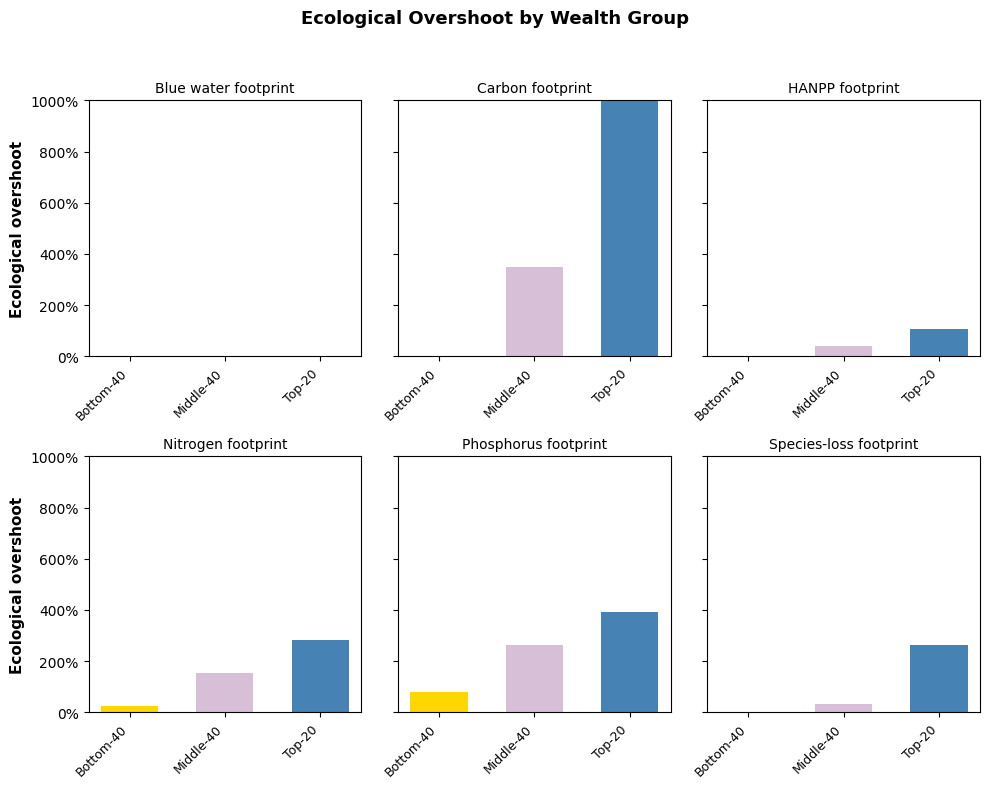

In [55]:
grp_data = pd.read_csv(os.path.join(BASE, 'myData', '11_20250127-grpDataAndShares.csv'))

eco_grp = grp_data[grp_data['domain'] == 'ecological'].copy()

# Overshoot percentage: clip negative ratios to zero (no overshoot)
eco_grp['overshoot_pct'] = eco_grp['ratio'].clip(lower=0) * 100

ECO_FOOTPRINT_NAMES = {
    'blueH2O_footprint': 'Blue water footprint',
    'co2_footprint': 'Carbon footprint',
    'hanpp_footprint': 'HANPP footprint',
    'N_footprint': 'Nitrogen footprint',
    'P_footprint': 'Phosphorus footprint',
    'species_footprint': 'Species-loss footprint',
}

eco_grp = eco_grp[eco_grp['indicator'].isin(ECO_FOOTPRINT_NAMES)].copy()
eco_grp['indicator_label'] = eco_grp['indicator'].map(ECO_FOOTPRINT_NAMES)

ind_order = list(ECO_FOOTPRINT_NAMES.values())
grp_order = ['Bottom-40', 'Middle-40', 'Top-20']
colors = {'Bottom-40': '#FFD700', 'Middle-40': '#D8BFD8', 'Top-20': '#4682B4'}

fig, axes = plt.subplots(2, 3, figsize=(10, 8), sharey=True)

for idx, ind_label in enumerate(ind_order):
    ax = axes[idx // 3, idx % 3]
    subset = eco_grp[eco_grp['indicator_label'] == ind_label]
    for j, grp in enumerate(grp_order):
        row = subset[subset['group'] == grp]
        val = row['overshoot_pct'].values[0] if len(row) > 0 else 0
        ax.bar(j, val, color=colors[grp], width=0.6)
    ax.set_title(ind_label, fontsize=10)
    ax.set_xticks(range(3))
    ax.set_xticklabels(grp_order, rotation=45, ha='right', fontsize=9)
    ax.set_ylim(0, 1000)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f}%'))

for row_idx in range(2):
    axes[row_idx, 0].set_ylabel('Ecological overshoot', fontweight='bold', fontsize=11)

fig.suptitle('Ecological Overshoot by Wealth Group', fontweight='bold', fontsize=13, y=0.98)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('clusters_ecological.svg', bbox_inches='tight')
plt.show()

## Part 4: Social Shortfall by Wealth Group

Analogous to Part 3, countries are classified into **Bottom-40**, **Middle-40**, and **Top-20** wealth groups based on GNI per capita. The group-level dataset provides per-capita deprivation rates for **21 social indicators** across **12 dimensions** (food, health, education, income & work, water, energy, connectivity, housing, equality, social cohesion, political voice, and peace & justice).

Each indicator measures the share of the population experiencing a specific form of deprivation. Higher values indicate greater shortfall — more people lacking access to the social foundation. The trellis plot below reveals a stark pattern: the poorest countries carry the largest share of social shortfall on nearly every dimension, while the wealthiest rarely do.

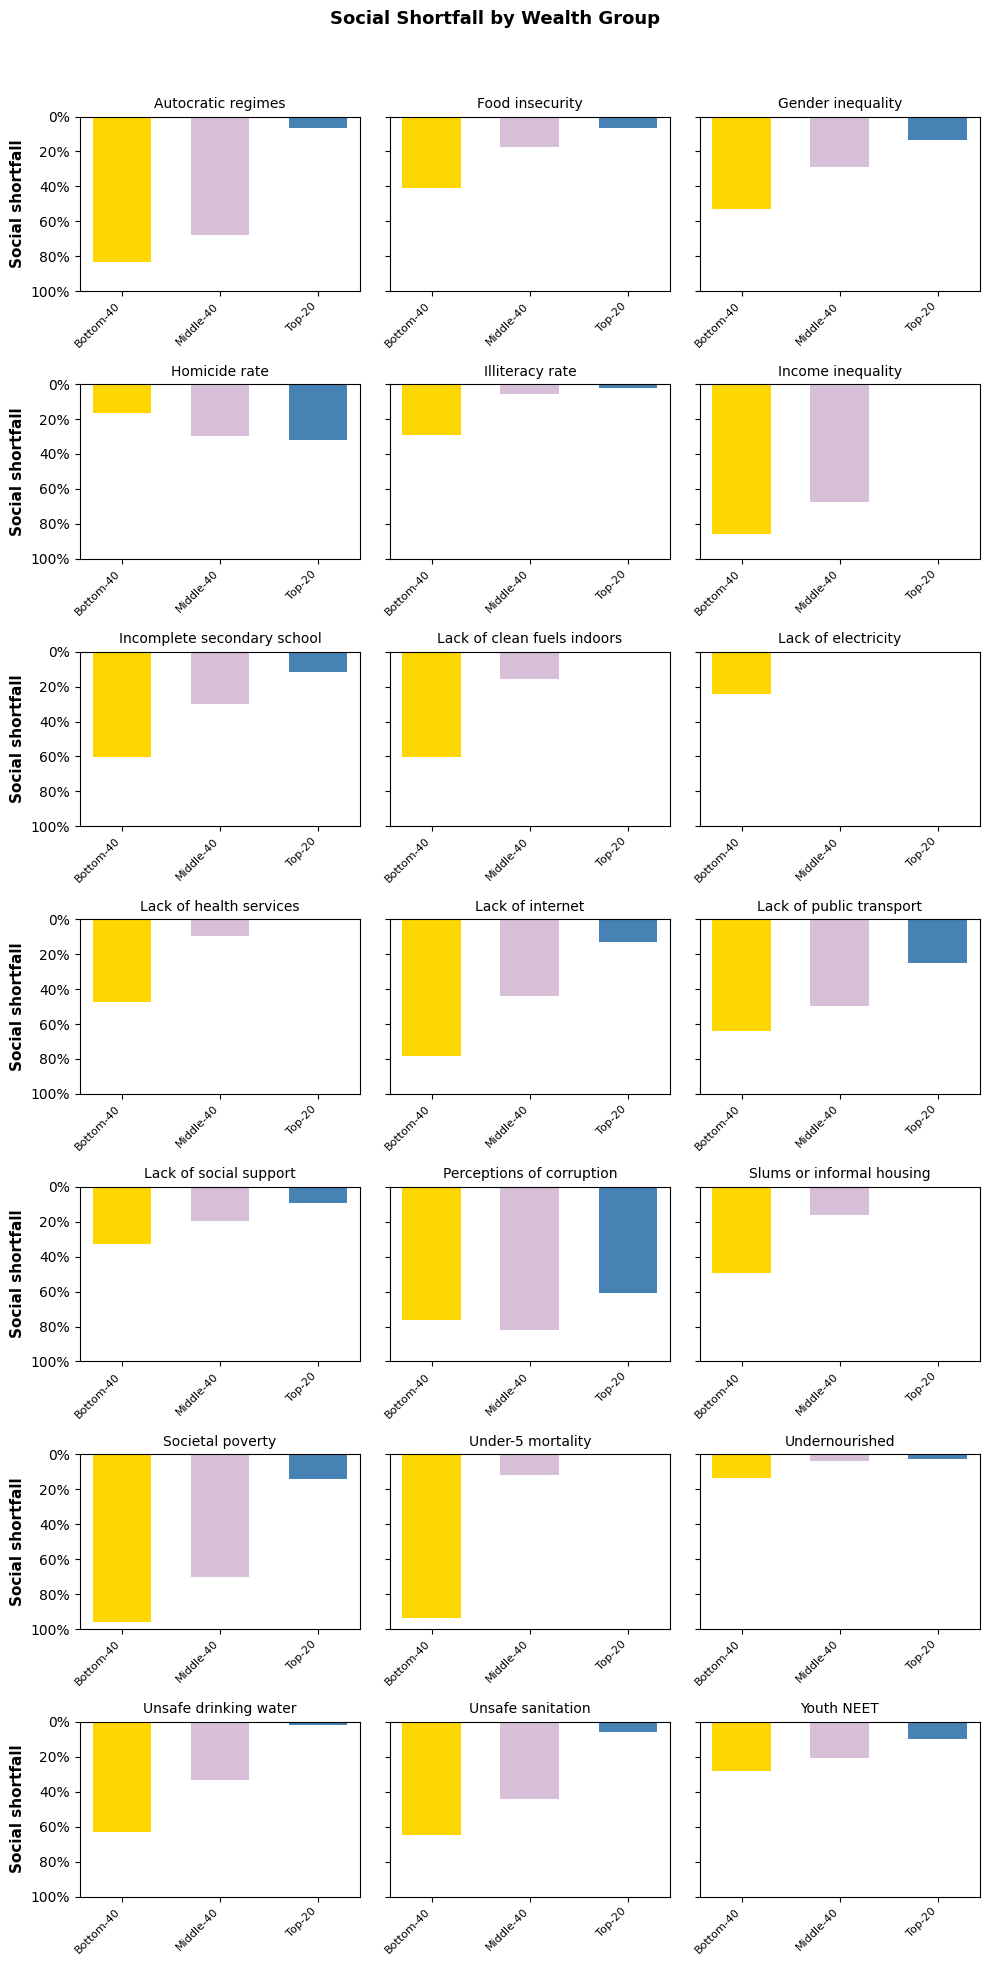

In [56]:
soc_grp = grp_data[grp_data['domain'] == 'social'].copy()

SOC_INDICATOR_NAMES = {
    'govRegimes': 'Autocratic regimes',
    'foodInsecurity': 'Food insecurity',
    'genderGapIndex': 'Gender inequality',
    'homicideOver5': 'Homicide rate',
    'adultLiteracy': 'Illiteracy rate',
    'palma': 'Income inequality',
    'secondarySchool': 'Incomplete secondary school',
    'energyIndoor': 'Lack of clean fuels indoors',
    'energyAccess': 'Lack of electricity',
    'UHCindex': 'Lack of health services',
    'internet': 'Lack of internet',
    'publicTrans': 'Lack of public transport',
    'socialSupport': 'Lack of social support',
    'controlCorruption': 'Perceptions of corruption',
    'urbanSlums': 'Slums or informal housing',
    'societalPoverty': 'Societal poverty',
    'under5death': 'Under-5 mortality',
    'undernourishment': 'Undernourished',
    'drinkingH2O': 'Unsafe drinking water',
    'sanitation': 'Unsafe sanitation',
    'youthNEET': 'Youth NEET',
}

soc_grp = soc_grp[soc_grp['indicator'].isin(SOC_INDICATOR_NAMES)].copy()
soc_grp['indicator_label'] = soc_grp['indicator'].map(SOC_INDICATOR_NAMES)

soc_ind_order = sorted(SOC_INDICATOR_NAMES.values())
grp_order = ['Bottom-40', 'Middle-40', 'Top-20']
colors = {'Bottom-40': '#FFD700', 'Middle-40': '#D8BFD8', 'Top-20': '#4682B4'}

n_indicators = len(soc_ind_order)
n_cols = 3
n_rows = (n_indicators + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 2.8 * n_rows), sharey=True)

for idx, ind_label in enumerate(soc_ind_order):
    ax = axes[idx // n_cols, idx % n_cols]
    subset = soc_grp[soc_grp['indicator_label'] == ind_label]
    for j, grp in enumerate(grp_order):
        row = subset[subset['group'] == grp]
        val = row['value'].values[0] if len(row) > 0 else 0
        ax.bar(j, val, color=colors[grp], width=0.6)
    ax.set_title(ind_label, fontsize=10)
    ax.set_xticks(range(3))
    ax.set_xticklabels(grp_order, rotation=45, ha='right', fontsize=8)
    ax.set_ylim(0, 100)
    ax.invert_yaxis()
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f}%'))

for idx in range(n_indicators, n_rows * n_cols):
    axes[idx // n_cols, idx % n_cols].set_visible(False)

for row_idx in range(n_rows):
    axes[row_idx, 0].set_ylabel('Social shortfall', fontweight='bold', fontsize=11)

fig.suptitle('Social Shortfall by Wealth Group', fontweight='bold', fontsize=13, y=1.0)
fig.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig('clusters_social.svg', bbox_inches='tight')
plt.show()

## Part 5: Sandwich Plot — Ecological Overshoot and Social Shortfall

The sandwich plot shows both the ecological overshoot and the social shortfall side by side, illustrating how each indicator changed between the start and end of the observation period (~2000–2022). The **top panel** shows ecological overshoot (percentage above the planetary boundary) and the **bottom panel** shows social shortfall (percentage of the population falling short).

Light red bars show the reduction in shortfall or overshoot between the start and end periods. Dark red bars show the increase in shortfall or overshoot between the start and end periods.

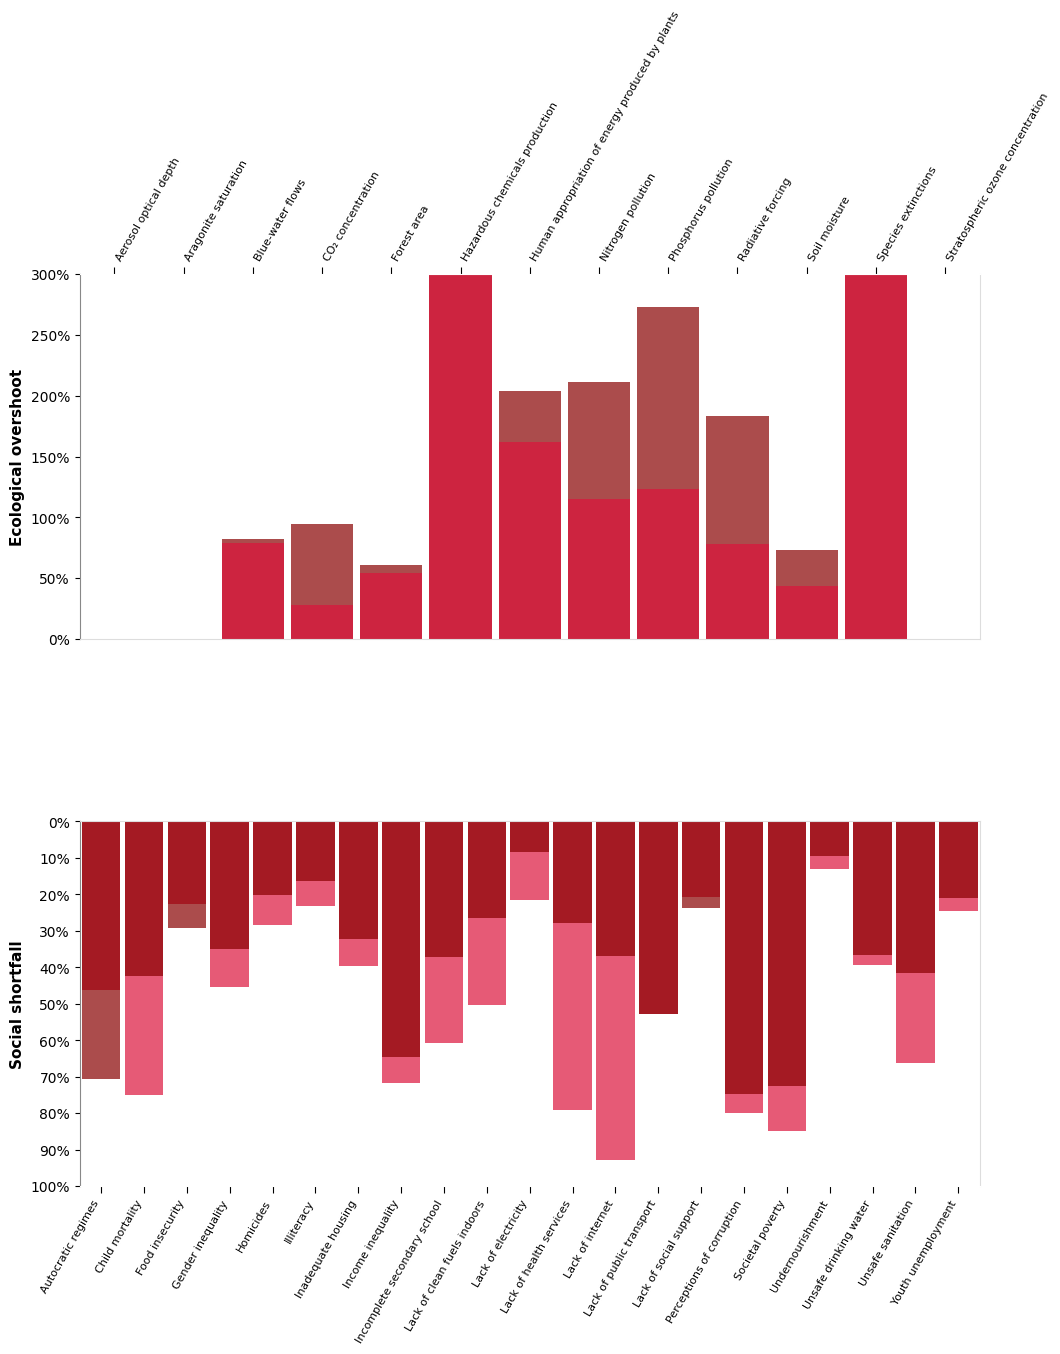

In [57]:
tables_path = os.path.join(BASE, 'myData', '9_20250516_Doughnut-GlobalTablesData.csv')
tables = pd.read_csv(tables_path)
tables = tables[tables['group'] == 'World'].copy()

eco_name_map = {
    'co2_ppm': 'CO₂ concentration',
    'erf_wm2': 'Radiative forcing',
    'omega_a': 'Aragonite saturation',
    'chemicalsMt_Hzd': 'Hazardous chemicals production',
    'phosphorusMt': 'Phosphorus pollution',
    'nitrogenMt': 'Nitrogen pollution',
    'interhemAOD': 'Aerosol optical depth',
    'blueDev': 'Blue-water flows',
    'soilDev': 'Soil moisture',
    'forestAreaMKM2': 'Forest area',
    'extinction1900': 'Species extinctions',
    'hanppGtC': 'Human appropriation of energy produced by plants',
    'totalOzone': 'Stratospheric ozone concentration',
}

soc_name_map = {
    'undernourishment': 'Undernourishment',
    'foodInsecurity': 'Food insecurity',
    'under5death': 'Child mortality',
    'UHCindex': 'Lack of health services',
    'adultLiteracy': 'Illiteracy',
    'secondarySchool': 'Incomplete secondary school',
    'societalPoverty': 'Societal poverty',
    'youthNEET': 'Youth unemployment',
    'drinkingH2O': 'Unsafe drinking water',
    'sanitation': 'Unsafe sanitation',
    'energyAccess': 'Lack of electricity',
    'energyIndoor': 'Lack of clean fuels indoors',
    'publicTrans': 'Lack of public transport',
    'internet': 'Lack of internet',
    'urbanSlums': 'Inadequate housing',
    'genderGapIndex': 'Gender inequality',
    'socialSupport': 'Lack of social support',
    'palma': 'Income inequality',
    'govRegimes': 'Autocratic regimes',
    'controlCorruption': 'Perceptions of corruption',
    'homicideOver5': 'Homicides',
}

eco = tables[tables['domain'] == 'ecological'].copy()
soc = tables[tables['domain'] == 'social'].copy()

eco['name'] = eco['indicator'].map(eco_name_map)
soc['name'] = soc['indicator'].map(soc_name_map)
eco = eco.dropna(subset=['name'])
soc = soc.dropna(subset=['name'])

# Ecological overshoot: use ratioStart/ratioEnd; negative ratios (below boundary) clipped to 0
eco['start'] = pd.to_numeric(eco['ratioStart'], errors='coerce').clip(lower=0).fillna(0)
eco['end'] = pd.to_numeric(eco['ratioEnd'], errors='coerce').clip(lower=0).fillna(0)

# Social shortfall: use valueStart/valueEnd; fill missing start values with end (e.g. publicTrans)
soc['start'] = pd.to_numeric(soc['valueStart'], errors='coerce')
soc['end'] = pd.to_numeric(soc['valueEnd'], errors='coerce')
soc['start'] = soc['start'].fillna(soc['end'])
soc['end'] = soc['end'].fillna(soc['start'])

eco = eco.sort_values('name').reset_index(drop=True)
soc = soc.sort_values('name').reset_index(drop=True)

fig, (ax_eco, ax_soc) = plt.subplots(2, 1, figsize=(10, 12),
                                      gridspec_kw={'hspace': 0.5})

CRIMSON, DARK_RED, ALPHA, W = '#DC143C', '#880000', 0.7, 0.9

# ── Top panel: ecological overshoot (bars grow upward) ──
x = np.arange(len(eco))
ax_eco.bar(x, eco['end'], W, color=DARK_RED, alpha=ALPHA)
ax_eco.bar(x, eco['start'], W, color=CRIMSON, alpha=ALPHA)
ax_eco.set_ylim(0, 300)
ax_eco.set_ylabel('Ecological overshoot', fontweight='bold', fontsize=11)
ax_eco.yaxis.set_major_locator(plt.MultipleLocator(50))
ax_eco.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f}%'))
ax_eco.set_xticks(x)
ax_eco.set_xticklabels(eco['name'], rotation=60, ha='left', fontsize=8)
ax_eco.xaxis.tick_top()
ax_eco.tick_params(axis='x', length=5)
ax_eco.set_xlim(-0.5, len(eco) - 0.5)

# ── Bottom panel: social shortfall (bars grow downward) ──
x2 = np.arange(len(soc))
ax_soc.bar(x2, soc['start'], W, color=CRIMSON, alpha=ALPHA)
ax_soc.bar(x2, soc['end'], W, color=DARK_RED, alpha=ALPHA)
ax_soc.set_ylim(100, 0)
ax_soc.set_ylabel('Social shortfall', fontweight='bold', fontsize=11)
ax_soc.yaxis.set_major_locator(plt.MultipleLocator(10))
ax_soc.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f}%'))
ax_soc.set_xticks(x2)
ax_soc.set_xticklabels(soc['name'], rotation=60, ha='right', fontsize=8)
ax_soc.tick_params(axis='x', length=5)
ax_soc.set_xlim(-0.5, len(soc) - 0.5)

for ax in (ax_eco, ax_soc):
    for spine in ax.spines.values():
        spine.set_edgecolor('#ddd')
    ax.spines['left'].set_edgecolor('#888')
ax_eco.spines['top'].set_edgecolor('white')
ax_soc.spines['bottom'].set_edgecolor('white')

fig.subplots_adjust(left=0.08, right=0.98, top=0.88, bottom=0.12)
plt.savefig('sandwich.svg', bbox_inches='tight')
plt.show()

## Part 6: Interactive Doughnut Plot

The doughnut plot is the signature visualization of the Doughnut Economics framework. The **inner ring** shows the social foundation — the minimum standard of well-being below which people experience deprivation — with wedges growing *inward* from the green boundary toward the center: larger shortfall means the wedge extends further in, encroaching on the safe space. The **outer ring** shows the ecological ceiling, with wedges growing *outward*: larger overshoot means the wedge extends further out, breaching the planetary boundary. The thick green band between them — labelled *Social Foundation* and *Ecological Ceiling* — is the **safe and just space**.

### Area-proportional wedges

The authors note that in their original chart, "values are proportional to the length of each wedge, which leads to a quadratic scaling of wedge area that may lead some readers to perceive small changes as more significant than they are." Here we correct this by making wedge **area** directly proportional to the indicator value.

For a social wedge with fixed outer radius \(R\) and variable inner radius \(r\):

\[\text{area} = \tfrac{1}{2}\,\Delta\theta\,(R^2 - r^2) \propto \text{value} \;\Longrightarrow\; r = \sqrt{R^2 - \alpha\,\text{value}}\]

For an ecological wedge with fixed inner radius \(R\) and variable outer radius \(r\):

\[r = \sqrt{R^2 + \alpha\,\text{value}}\]

Ecological overshoot values are divided by 4 to keep the outer ring visually balanced.

### Visual encoding

Each social indicator is shown with a **light pink background** (start-period shortfall, ~2000) and a **coloured foreground** (end-period shortfall, ~2022). Where the light pink extends beyond the colour, that dimension improved. Colour intensity encodes magnitude on a pink-to-maroon scale. Ecological indicators show the end-period value only, also colour-coded by intensity. Hover over any wedge for detailed values.

In [64]:
import plotly.graph_objects as go
from IPython.display import IFrame

SOC_ORD = ['food', 'health', 'education', 'income and work', 'peace and justice', 
           'political voice', 'social cohesion', 'equality', 'housing', 'connectivity',
           'energy', 'water',  
           ]
ECO_ORD = ['climate change', 'ocean acidification', 'chemical pollution',
           'nutrient pollution', 'air pollution', 'freshwater disruption',
           'land conversion', 'biodiversity breakdown', 'ozone depletion']

soc_d = (soc.assign(_o=soc['dimension'].map({d: i for i, d in enumerate(SOC_ORD)}))
         .sort_values(['_o', 'name']).drop(columns='_o').reset_index(drop=True))
eco_d = (eco.assign(_o=eco['dimension'].map({d: i for i, d in enumerate(ECO_ORD)}))
         .sort_values(['_o', 'name']).drop(columns='_o').reset_index(drop=True))

n_s, n_e = len(soc_d), len(eco_d)

# ── Radii ──
R0    = 0.03   # tiny center hole
RS    = 1.05   # outer edge of social wedges
RG1   = 1.19   # inner dark-green band inner edge
RG2   = 1.20   # inner dark-green band outer edge
RG3   = 1.45   # outer dark-green band inner edge
RG4   = 1.55   # outer dark-green band outer edge
RE    = 1.55   # inner edge of ecological wedges
REMAX = 2.80   # max ecological outer edge
EDIV  = 4.0    # ecological value divisor

# Area-proportional scaling
max_sv = max(soc_d['start'].max(), soc_d['end'].max())
max_ev = max(eco_d['start'].max(), eco_d['end'].max()) / EDIV
A_S = (RS**2 - R0**2) / max_sv
A_E = (REMAX**4 - RE**4) / max_ev

def s_rin(v):
    return np.sqrt(max(RS**2 - A_S * max(v, 0), R0**2))

def e_rout(v):
    return np.sqrt(RE**2 + A_E * max(v / EDIV, 0))

# Angular positions 
GAP_FRAC = 0.06
s_slot = 2 * np.pi / n_s
e_slot = 2 * np.pi / n_e
sa = [(np.pi/2 - i*s_slot, np.pi/2 - i*s_slot - s_slot*(1-GAP_FRAC)) for i in range(n_s)]
ea = [(np.pi/2 - i*e_slot, np.pi/2 - i*e_slot - e_slot*(1-GAP_FRAC)) for i in range(n_e)]

# Polygon helpers
def make_wedge(ri, ro, a0, a1, n=40):
    lo, hi = min(a0, a1), max(a0, a1)
    t = np.linspace(lo, hi, n)
    x = np.concatenate([ro*np.cos(t), ri*np.cos(t[::-1]), [ro*np.cos(t[0])]])
    y = np.concatenate([ro*np.sin(t), ri*np.sin(t[::-1]), [ro*np.sin(t[0])]])
    return x.tolist(), y.tolist()

def make_disc(r, n=100):
    t = np.linspace(0, 2*np.pi, n)
    return (r*np.cos(t)).tolist(), (r*np.sin(t)).tolist()

# Colour palette
_PAL = [(0,(255,198,196)),(0.10,(239,152,161)),(0.30,(214,111,134)),
        (0.5,(173,70,108)),(0.69,(102,31,67)), (1.0,(103,32,68))]

def val_color(v, lo, hi):
    if hi <= lo or v <= 0:
        return 'rgb(255,245,240)'
    t = min(max((v - lo) / (hi - lo), 0), 1)
    for j in range(len(_PAL) - 1):
        if t <= _PAL[j+1][0]:
            f = (t - _PAL[j][0]) / (_PAL[j+1][0] - _PAL[j][0])
            a, b = _PAL[j][1], _PAL[j+1][1]
            return f'rgb({int(a[0]+f*(b[0]-a[0]))},{int(a[1]+f*(b[1]-a[1]))},{int(a[2]+f*(b[2]-a[2]))})'
    return 'rgb(103,32,68)'

#Trace helper
def add_wedge(fig, ri, ro, a0, a1, color, hover_text=None):
    x, y = make_wedge(ri, ro, a0, a1)
    kw = dict(x=x, y=y, fill='toself', fillcolor=color,
              line=dict(width=0), mode='lines', showlegend=False)
    if hover_text is None:
        kw['hoverinfo'] = 'skip'
    else:
        kw['name'] = hover_text
        kw['hoverinfo'] = 'text'
        kw['text'] = [hover_text] * len(x)
        kw['hovertemplate'] = '%{text}<extra></extra>'
    fig.add_trace(go.Scatter(**kw))

#Build figure 
fig = go.Figure()

# Green zone — three layered filled discs (dark / light / white inner)
for r, c in [(RG4, '#227443'), (RG3, '#6eb446'), (RG2, '#227443'), (RS, 'white')]:
    x, y = make_disc(r)
    fig.add_trace(go.Scatter(x=x, y=y, fill='toself', fillcolor=c,
        line=dict(width=0), mode='lines', showlegend=False, hoverinfo='skip'))

# Social backgrounds — one pizza slice per dimension (visual grouping)
BG = 'rgb(255,245,240)'
_soc_dim_spans = soc_d.groupby('dimension', sort=False).agg(
    i0=('name', lambda x: x.index.min()), i1=('name', lambda x: x.index.max())
).reset_index()
for _, row in _soc_dim_spans.iterrows():
    i0, i1 = int(row['i0']), int(row['i1'])
    add_wedge(fig, R0, RS, sa[i0][0], sa[i1][1], BG)

# Social per-indicator background overlays (for hover on empty areas)
for i in range(n_s):
    v = soc_d.loc[i, 'end']
    nm = soc_d.loc[i, 'name']
    add_wedge(fig, R0, RS, *sa[i], BG, f"{nm}: {v:.2f}%")

# Social start-period shortfall wedges
for i in range(n_s):
    add_wedge(fig, s_rin(soc_d.loc[i, 'start']), RS, *sa[i], BG,
              f"{soc_d.loc[i, 'name']}: {soc_d.loc[i, 'start']:.2f}%")

# Social coloured wedges — end-period shortfall, colour intensity ∝ value
sv = soc_d['end'].values
s_lo, s_hi = sv[sv > 0].min(), sv.max()
for i in range(n_s):
    v = soc_d.loc[i, 'end']
    nm = soc_d.loc[i, 'name']
    add_wedge(fig, s_rin(v), RS, *sa[i], val_color(v, s_lo, s_hi),
              f"{nm}: {v:.2f}%")

# Ecological coloured wedges — end-period overshoot
ev = eco_d['end'].values
e_lo = ev[ev > 0].min() if (ev > 0).any() else 0
e_hi = ev.max()
for i in range(n_e):
    v = eco_d.loc[i, 'end']
    if v <= 0:
        continue
    nm = eco_d.loc[i, 'name']
    add_wedge(fig, RE, e_rout(v), *ea[i], val_color(v, e_lo, e_hi),
              f"{nm}: {v:.2f}%")

#Annotations 
ann = []

def curved_text(label, r, span_deg=60):
    span = np.radians(span_deg)
    for ch, a in zip(label, np.linspace(np.pi/2 + span/2, np.pi/2 - span/2, len(label))):
        ann.append(dict(x=float(r*np.cos(a)), y=float(r*np.sin(a)),
            text=ch, showarrow=False, textangle=float(90 - np.degrees(a)),
            font=dict(color='white', family='roboto', size=7, weight='bold'),
            valign='bottom', width=11))

curved_text('ECOLOGICAL CEILING', (RG3 + RG4) / 2)
curved_text('SOCIAL FOUNDATION', (RG1 + RG2) / 2.15)

def tangent_angle(mid_angle):
    d = np.degrees(mid_angle) % 360
    return (270 - d) if 90 < d < 270 else (90 - d)

# Social dimension labels (on the lighter-green band)
soc_dims = soc_d.groupby('dimension', sort=False).agg(
    i0=('name', lambda x: x.index.min()), i1=('name', lambda x: x.index.max())
).reset_index()
dim_r = (RG2 + RG3) / 2
for _, row in soc_dims.iterrows():
    i0, i1 = int(row['i0']), int(row['i1'])
    ma = (sa[i0][0] + sa[i1][1]) / 2
    ann.append(dict(x=float(dim_r*np.cos(ma)), y=float(dim_r*np.sin(ma)),
        text=row['dimension'], showarrow=False, textangle=float(tangent_angle(ma)),
        font=dict(color='white', family='roboto', size=7, weight='bold')))

# Ecological dimension labels (outside the wedges)
eco_dims = eco_d.groupby('dimension', sort=False).agg(
    i0=('name', lambda x: x.index.min()), i1=('name', lambda x: x.index.max())
).reset_index()
for _, row in eco_dims.iterrows():
    i0, i1 = int(row['i0']), int(row['i1'])
    ma = (ea[i0][0] + ea[i1][1]) / 2
    max_r = max(e_rout(eco_d.loc[j, 'end']) for j in range(i0, i1 + 1))
    lr = max(max_r, RE + 0.1) + 0.15
    ann.append(dict(x=float(lr*np.cos(ma)), y=float(lr*np.sin(ma)),
        text=row['dimension'].replace(' ', '<br>'), showarrow=False,
        textangle=float(tangent_angle(ma)),
        font=dict(color='black', size=8, weight='bold')))

#Layout 
fig.update_layout(
    annotations=ann,
    xaxis=dict(visible=False, range=[-3.0, 3.0]),
    yaxis=dict(visible=False, range=[-3.0, 3.0], scaleanchor='x', scaleratio=1),
    width=700, height=700,
    margin=dict(l=10, r=10, t=10, b=10),
    plot_bgcolor='white', paper_bgcolor='white',
    hoverlabel=dict(font=dict(size=14, family='Arial'), bgcolor='rgba(255,255,255,0.8)'),
)

fig.write_html('doughnut.html')
IFrame('doughnut.html', width='100%', height=600)